In [1]:
from torch import nn
import kagglehub
import torch
from torch import Tensor
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torchvision import datasets, transforms
import torchvision.models as models
from torch.optim import Adam, SGD
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader, random_split, ConcatDataset
import seaborn as sns
from PIL import Image
from pathlib import Path
from timeit import default_timer as timer
import cv2
import timm

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not Path('/home/var-roman/.cache/kagglehub/datasets/siddharthkumarsah/logo-dataset-2341-classes-and-167140-images/versions/1/datasetcopy/traindataset/').exists():
    kagglehub.dataset_download('siddharthkumarsah/logo-dataset-2341-classes-and-167140-images')
dataset_path = '/home/var-roman/Desktop/For_studying/7_semester/PR_PZ/Lab6/dataset_mizuno/'

print("Path to dataset files:", dataset_path)
print('Device: ', device)

Path to dataset files: /home/var-roman/Desktop/For_studying/7_semester/PR_PZ/Lab6/dataset_mizuno/
Device:  cuda


In [3]:
IMG_SIZE = 299
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_CLASSES = 1

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

train_dataset = datasets.ImageFolder(root=dataset_path + 'train', transform=train_transform)
test_dataset = datasets.ImageFolder(root=dataset_path + 'test', transform=basic_transform)

# additional_train_dataset, augment_train_dataset = random_split(train_dataset, [len(train_dataset) // 2, len(train_dataset) // 2 + 1])
#
# augment_train_dataset.dataset.transform = train_transform
# train_dataset = ConcatDataset([train_dataset, augment_train_dataset])
train_dataset.classes = ['mizuno', 'negative']

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS,
                              pin_memory=True)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS,
                             pin_memory=True)

print(f"Дані завантажено. Класи: {train_dataset.classes}")

Дані завантажено. Класи: ['mizuno', 'negative']


In [4]:
class_names = train_dataset.classes
NUM_CLASSES = 1

print(f"Кількість класів: {NUM_CLASSES} (Бінарна класифікація)")
print(f"Імена класів: {class_names}")

Кількість класів: 1 (Бінарна класифікація)
Імена класів: ['mizuno', 'negative']


In [5]:
def training_step(model: torch.nn.Module,
                  data_loader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  optimizer: torch.optim.Optimizer) -> float:

    loss_count: float = 0.0
    model.train()
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        output_logits = model(X)
        y = y.float().unsqueeze(1)
        loss = loss_fn(output_logits, y)
        loss_count += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_count /= len(data_loader)
    return loss_count


def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    all_preds = []
    all_labels = []
    test_loss = 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            y_float = y.float().unsqueeze(1)
            test_loss += loss_fn(test_pred_logits, y_float).item()
            preds = torch.round(torch.sigmoid(test_pred_logits))

            all_preds.append(preds.cpu().flatten())
            all_labels.append(y.cpu())

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        test_loss /= len(data_loader)

        return test_loss, all_preds, all_labels


def save_model(model: torch.nn.Module, model_name: str):
    model_path = Path("models")
    model_path.mkdir(parents=True,
                     exist_ok=True)

    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name

    print(f"Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(), f=model_save_path)

def load_model(model: torch.nn.Module, model_name: str) -> torch.nn.Module:
    model_path = Path("models")
    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name
    model.load_state_dict(torch.load(f=model_save_path,weights_only=True))
    model = model.to(device)
    return model

def predict_image(model: torch.nn.Module, image_path: str, transform: transforms.Compose, class_names: list):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Не вдалося знайти файл зображення за шляхом {image_path}")
        return None, None
    except Exception as e:
        print(f"Помилка: Не вдалося відкрити зображення {image_path}. {e}")
        return None, None
    model.to(device)
    model.eval()
    try:
        img_transformed = transform(img).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Помилка під час трансформації зображення: {e}")
        return None, None
    with torch.inference_mode():
        pred_logits = model(img_transformed)
        pred_prob = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_prob, dim=1)

    pred_class_name = class_names[pred_label.cpu().item()]
    predicted_probability = pred_prob.max().cpu().item()
    return pred_class_name, predicted_probability

def calc_metrics(y_preds, y_true, epochs_train_lt, epochs_test_lt,
                 epochs_num, model_name, num_classes):
    acc_fn = Accuracy(task="binary")
    accuracy = acc_fn(y_preds, y_true)
    print(f"Загальна точність (Accuracy): {accuracy.item():.4f}")

    conf_matrix_fn = ConfusionMatrix(task="binary")
    prec_fn_macro = Precision(task="binary", average='macro')
    recall_fn_macro = Recall(task="binary", average='macro')
    f1_fn_macro = F1Score(task="binary", average='macro')

    conf_matrix = conf_matrix_fn(y_preds, y_true).numpy()
    precision_macro = prec_fn_macro(y_preds, y_true)
    recall_macro = recall_fn_macro(y_preds, y_true)
    f1_macro = f1_fn_macro(y_preds, y_true)

    print(f"Усереднена прецизійність (Macro Precision): {precision_macro.item():.4f}")
    print(f"Усереднена повнота (Macro Recall): {recall_macro.item():.4f}")
    print(f"Усереднений F1-Score (Macro F1-Score): {f1_macro.item():.4f}")

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax = ax[0]
    )
    ax[0].set_xlabel('Передбачений клас (Predicted Label)')
    ax[0].set_ylabel('Справжній клас (True Label)')
    ax[0].set_title('Матриця помилок (Confusion Matrix)')

    ax[1].plot(range(epochs_num), epochs_train_lt, label="Train loss")
    ax[1].plot(range(epochs_num), epochs_test_lt, label="Test loss")
    ax[1].set_title(f"Модель: {model_name}")
    ax[1].set_ylabel("Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].legend()
    plt.show()

def predict_image(model: torch.nn.Module, image_path: str, transform: transforms.Compose, class_names: list):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Не вдалося знайти файл зображення за шляхом {image_path}")
        return None, None
    except Exception as e:
        print(f"Помилка: Не вдалося відкрити зображення {image_path}. {e}")
        return None, None
    model.to(device)
    model.eval()
    try:
        img_transformed = transform(img).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Помилка під час трансформації зображення: {e}")
        return None, None
    with torch.inference_mode():
        pred_logits = model(img_transformed)
        pred_prob = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_prob, dim=1)

    pred_class_name = class_names[pred_label.cpu().item()]
    predicted_probability = pred_prob.max().cpu().item()
    return pred_class_name, predicted_probability

In [6]:
def print_train_time(start, end):
        total_time = end - start
        print(f"Загальний час тренування на {device}: {total_time:.3f} секунд")
        return total_time

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=in_channels,
            bias=bias)

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=bias
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.skip_connection = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels))

        self.main_path = nn.Sequential(
            nn.ReLU(),
            SeparableConv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            SeparableConv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.MaxPool2d(kernel_size=3, stride=stride, padding=1))

    def forward(self, x):
        skip = self.skip_connection(x)
        main = self.main_path(x)
        return skip + main

class MiddleFlowBlock(nn.Module):
    def __init__(self, channels=728):
        super().__init__()

        self.main_path = nn.Sequential(
            nn.ReLU(),
            SeparableConv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            SeparableConv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            SeparableConv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.main_path(x)

class Xception(nn.Module):
    def __init__(self, num_classes=10, ):
        super().__init__()

        self.entry_flow = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 728, stride=2))

        middle_flow_blocks = []
        for _ in range(8):
            middle_flow_blocks.append(MiddleFlowBlock(728))
        self.middle_flow = nn.Sequential(*middle_flow_blocks)

        self.exit_flow = nn.Sequential(
            ResidualBlock(728, 1024, stride=2),
            SeparableConv2d(1024, 1536, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1536),
            nn.ReLU(inplace=True),

            SeparableConv2d(1536, 2048, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True))

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.entry_flow(x)
        x = self.middle_flow(x)
        x = self.exit_flow(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


    # def _initialize_weights(self):
    #     for m in self.modules():
    #         if isinstance(m, (nn.Conv2d, nn.Linear)):
    #             if hasattr(m, 'stddev'):
    #                 nn.init.trunc_normal_(m.weight, mean=0.0, std=m.stddev, a=-2.0, b=2.0)
    #                 if m.bias is not None:
    #                     nn.init.constant_(m.bias, 0)
    #             else:
    #                 nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    #
    #         elif isinstance(m, nn.BatchNorm2d):
    #             nn.init.constant_(m.weight, 1)
    #             nn.init.constant_(m.bias, 0)

In [10]:
temp_model = timm.create_model('xception', pretrained=True)
pretrained_weights = temp_model.state_dict()

model = Xception(num_classes=NUM_CLASSES)
model.to(device)

keys_to_remove = ['fc.weight', 'fc.bias']
for key in keys_to_remove:
    if key in pretrained_weights:
        pretrained_weights.pop(key)
        print(f"Removed key: {key}")

print("\nLoading pre-trained weights into custom Xception...")
model.load_state_dict(pretrained_weights, strict=False)
print("Weights loaded successfully!")

for param in model.parameters():
    param.requires_grad = False

print("\nUnfreezing layers for training:")

layers_to_unfreeze = [
    model.fc,
    model.exit_flow,
    model.middle_flow,
    # model.entry_flow
]

for layer in layers_to_unfreeze:
    if layer is not None:
        for param in layer.parameters():
            param.requires_grad = True
            print(f" - Unfreezing params in: {layer.__class__.__name__}")

params_to_train = [p.shape for p in model.parameters() if p.requires_grad]
print(f"\nParameters to be trained shapes: {params_to_train}")

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001)

criterion = nn.BCEWithLogitsLoss()

Removed key: fc.weight
Removed key: fc.bias

Loading pre-trained weights into custom Xception...
Weights loaded successfully!

Unfreezing layers for training:
 - Unfreezing params in: Linear
 - Unfreezing params in: Linear
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params in: Sequential
 - Unfreezing params 

In [11]:
def training_process(num_epoch: int,
                     model: torch.nn.Module,
                     optimizer: torch.optim.Optimizer,
                     loss_fn: torch.nn.Module,
                     train_loader: DataLoader,
                     test_loader: DataLoader):
    train_time_start_on_gpu = timer()

    epochs_train_lt_1 = []
    epochs_test_lt_1 = []

    epochs = num_epoch
    for epoch in tqdm(range(epochs)):
        print(f"Epoch: {epoch}\n---------")

        train_loss_value = training_step(data_loader=train_loader,
                                         model=model,
                                         loss_fn=loss_fn,
                                         optimizer=optimizer)
        epochs_train_lt_1.append(train_loss_value)
        test_loss_var_1, y_preds_1, y_true_1 = test_step(data_loader=test_loader,
                                                         model=model,
                                                         loss_fn=loss_fn)

        epochs_test_lt_1.append(test_loss_var_1)

        print(f"Train loss: {train_loss_value:.4f} | Test loss: {test_loss_var_1:.4f}")


    train_time_end_on_gpu = timer()


    total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                                end=train_time_end_on_gpu)

    return epochs_train_lt_1, epochs_test_lt_1, y_preds_1, y_true_1, total_train_time_model_1

In [ ]:
epochs_count = 10
epochs_train_lt_1, epochs_test_lt_1, y_preds_1, y_true_1, total_train_time_model_1 = training_process(epochs_count, model, optimizer, criterion, train_dataloader, test_dataloader)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------


Загальна точність (Accuracy): 0.9989
Усереднена прецизійність (Macro Precision): 0.9992
Усереднена повнота (Macro Recall): 0.9997
Усереднений F1-Score (Macro F1-Score): 0.9994


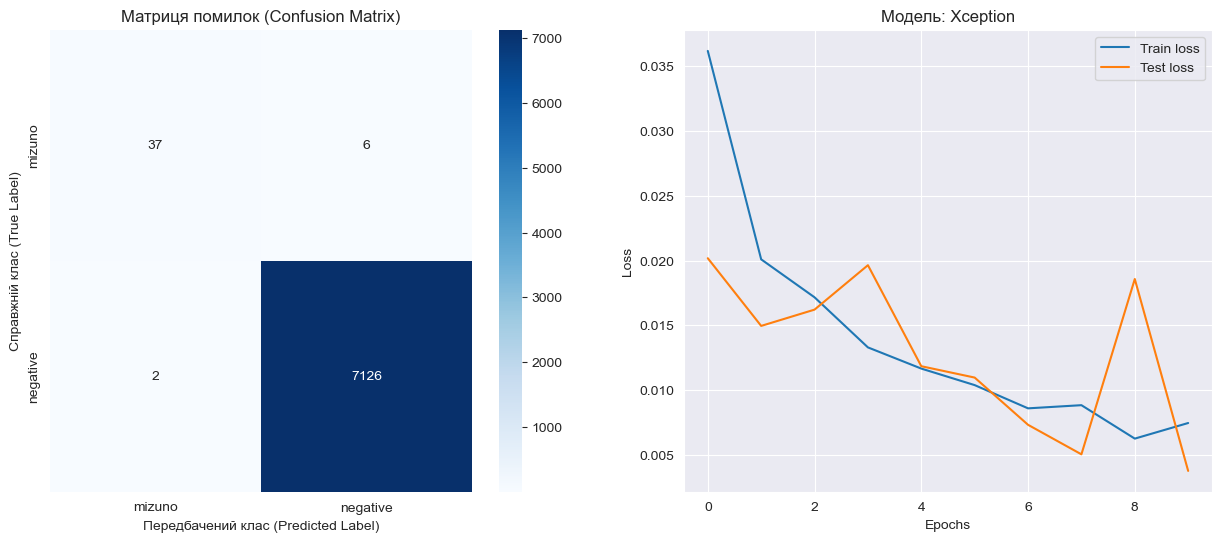

In [10]:
calc_metrics(y_preds=y_preds_1,
             y_true=y_true_1,
             epochs_train_lt=epochs_train_lt_1,
             epochs_test_lt=epochs_test_lt_1,
             epochs_num=epochs_count,
             model_name="Xception",
             num_classes=NUM_CLASSES)

In [11]:
save_model(model=model, model_name='Xception_v1_1')

Saving model to: models/Xception_v0_3.pth


In [16]:
model = load_model(model=model, model_name='Xception_v0_3')

## Video test

In [17]:
print("\nЗавдання 6: Обробка Відео")

VIDEO_PATH = "dataset_mizuno/Mizuno Running_ Forward We Go.mp4"
# MODEL_PATH = "models/Xception_v0.pth"
THRESHOLD = 0.5
# WINDOW_SIZE = 299
# STRIDE = 150

model = load_model(model=model, model_name='Xception_v0')
model.eval()

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print(f"Помилка: Не вдалося відкрити відео {VIDEO_PATH}")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Обробка відео: {frame_count} кадрів, FPS: {fps:.2f}")

    detected_frames = []

    with torch.inference_mode():
        for frame_idx in tqdm(range(frame_count)):
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            img_tensor = basic_transform(pil_img).unsqueeze(0).to(device)

            logit = model(img_tensor)
            prob = torch.sigmoid(logit).item()

            if prob < THRESHOLD:
                detected_frames.append(frame_idx)

    cap.release()

    if not detected_frames:
        print("Логотип 'Mizuno' не знайдено у відео.")
    else:
        print("\nЗвіт про виявлення 'Mizuno'")
        start_frame = detected_frames[0]
        end_frame = detected_frames[0]

        for frame in detected_frames[1:]:
            if frame == end_frame + 1:
                end_frame = frame
            else:
                start_time = start_frame / fps
                end_time = end_frame / fps
                print(f"Логотип виявлено: з {start_time:.2f}s по {end_time:.2f}s")
                start_frame = frame
                end_frame = frame

        start_time = start_frame / fps
        end_time = end_frame / fps
        print(f"Логотип виявлено: з {start_time:.2f}s по {end_time:.2f}s")


Завдання 6: Обробка Відео
Обробка відео: 1955 кадрів, FPS: 23.98


100%|█████████▉| 1952/1955 [00:19<00:00, 100.52it/s]

Логотип 'Mizuno' не знайдено у відео.


In [18]:
def process_video_batched(video_path, model, transform, threshold, batch_size=32):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Помилка відео: {video_path}")
        return [], [], 0

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Обробка відео (пакетний режим): {frame_count} кадрів, FPS: {fps:.2f}")

    frame_indices = []
    frame_probs = []

    batch_frames_pil = []
    batch_indices = []

    current_frame_idx = 0

    with torch.inference_mode():
        pbar = tqdm(total=frame_count)
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)

            batch_frames_pil.append(pil_img)
            batch_indices.append(current_frame_idx)
            current_frame_idx += 1

            if len(batch_frames_pil) == batch_size:
                tensors = [transform(img) for img in batch_frames_pil]
                batch_tensor = torch.stack(tensors).to(device)

                logits = model(batch_tensor)
                probs = torch.sigmoid(logits).cpu().squeeze().tolist()

                frame_probs.extend(probs)
                frame_indices.extend(batch_indices)

                batch_frames_pil = []
                batch_indices = []

            pbar.update(1)

        if batch_frames_pil:
            tensors = [transform(img) for img in batch_frames_pil]
            batch_tensor = torch.stack(tensors).to(device)
            logits = model(batch_tensor)
            probs = torch.sigmoid(logits).cpu().squeeze().tolist()

            if isinstance(probs, float):
                probs = [probs]

            frame_probs.extend(probs)
            frame_indices.extend(batch_indices)

        pbar.close()

    cap.release()
    print("Пакетна обробка завершена.")
    return frame_indices, frame_probs, fps

def post_process_and_report_timestamps(frame_indices, frame_probs, fps, threshold, smoothing_window=5):
    probs_np = np.array(frame_probs)
    if smoothing_window > 1:
        kernel = np.ones(smoothing_window) / smoothing_window
        smoothed_probs = np.convolve(probs_np, kernel, mode='valid')
        offset = (smoothing_window - 1) // 2
        smoothed_indices = frame_indices[offset : -offset]
        if len(smoothed_indices) != len(smoothed_probs):
             smoothed_indices = frame_indices[offset : -(offset+1)]

    else:
        smoothed_probs = probs_np
        smoothed_indices = frame_indices

    predictions = (smoothed_probs < threshold).astype(int)

    print("\nЗвіт про виявлення (після пост-обробки)")

    start_frame = -1
    for i in range(len(predictions)):
        frame_idx = smoothed_indices[i]

        # Початок нового проміжку
        if predictions[i] == 1 and (i == 0 or predictions[i-1] == 0):
            start_frame = frame_idx

        # Кінець проміжку
        if predictions[i] == 0 and i > 0 and predictions[i-1] == 1:
            end_frame = smoothed_indices[i-1]
            start_time = start_frame / fps
            end_time = end_frame / fps
            if end_time > start_time:
                 print(f"Логотип виявлено [Згладжено]: з {start_time:.2f}s по {end_time:.2f}s")
            start_frame = -1

    if start_frame != -1:
        end_frame = smoothed_indices[-1]
        start_time = start_frame / fps
        end_time = end_frame / fps
        print(f"Логотип виявлено [Згладжено]: з {start_time:.2f}s по {end_time:.2f}s")

    plt.figure(figsize=(15, 5))
    plt.plot(frame_indices, probs_np, label='Сирі ймовірності', alpha=0.4, color='blue')
    plt.plot(smoothed_indices, smoothed_probs, label=f'Згладжені (вікно={smoothing_window})', color='red')
    plt.axhline(threshold, color='black', linestyle=':', label=f'Поріг ({threshold})')
    plt.title('Порівняння сирих та згладжених передбачень')
    plt.xlabel('Кадр')
    plt.ylabel('Ймовірність логотипу')
    plt.legend()
    plt.show()

Крок 1: Пакетна обробка
Обробка відео (пакетний режим): 1955 кадрів, FPS: 23.98


100%|█████████▉| 1952/1955 [00:21<00:00, 89.68it/s]

Пакетна обробка завершена.

Крок 2: Пост-обробка

Звіт про виявлення (після пост-обробки)


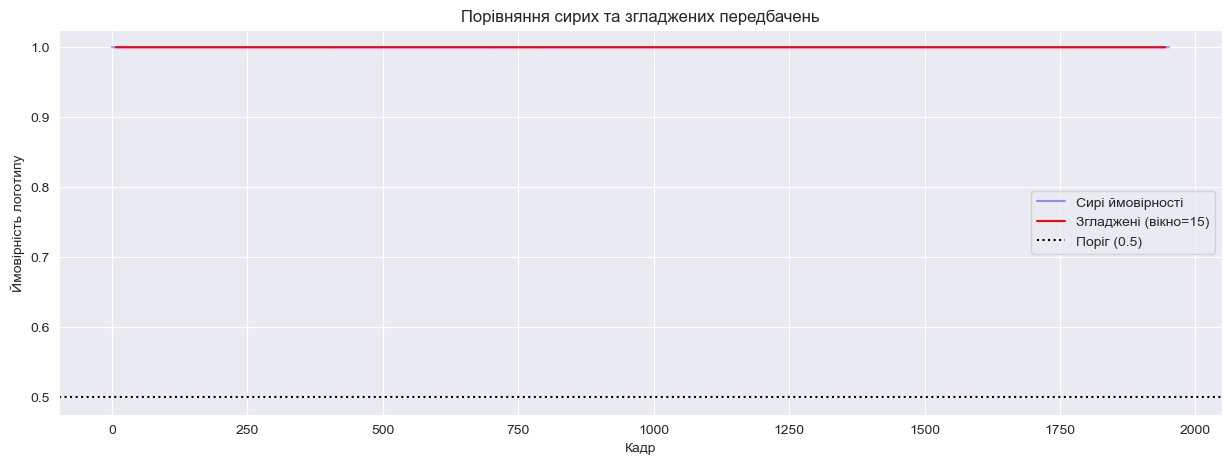

In [19]:
print("Крок 1: Пакетна обробка")
(frame_indices, frame_probs, fps) = process_video_batched(
    VIDEO_PATH, model, basic_transform, THRESHOLD, batch_size=BATCH_SIZE)

print("\nКрок 2: Пост-обробка")
post_process_and_report_timestamps(
    frame_indices, frame_probs, fps, threshold=THRESHOLD, smoothing_window=15)